# 03 — Sample-level pseudobulk DE, sex × treatment interaction and pathway enrichment

This is the major methodological revision.

The original workflow treated individual cells as independent observations and ran `rank_genes_groups` after scaling/HVG selection. The reviewer correctly noted that the biological replicate is the **sample**, not the cell.

This notebook therefore:
1. aggregates raw counts across cells within each biological sample;
2. performs DESeq2-style negative-binomial modelling with PyDESeq2;
3. uses **all retained genes**, not only the 2,000 HVGs;
4. tests cocaine vs sucrose within the full 2×2 design;
5. explicitly tests the sex × treatment interaction;
6. reports descriptive male/female gene counts without treating their difference as a formal sex-difference test;
7. avoids undefined fold-change values by using the count-based model and documents low-count filtering;
8. regenerates volcano and enrichment figures directly from the new result tables;
9. separates significant and non-significant enrichment terms.

**Important:** install PyDESeq2 before running:
`uv pip install pydeseq2`

In [1]:
from pathlib import Path
import gc
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

SEED = 42
np.random.seed(SEED)

ROOT = Path("..")
RESULTS_DIR = ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(RESULTS_DIR / "adata_clustered.h5ad")
print(adata)
print("Counts layer:", adata.layers["counts"].shape)

AnnData object with n_obs × n_vars = 88922 × 11946
    obs: 'sample', 'sex', 'treatment', 'replicate', 'condition', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'sample_batch', 'leiden_res_0_5', 'leiden_res_0_8', 'leiden_res_1_0', 'leiden_res_1_2', 'cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'gene_symbol'
    uns: 'cell_type_colors', 'condition_colors', 'hvg', 'leiden_res_0_5', 'leiden_res_0_8', 'leiden_res_0_8_colors', 'leiden_res_1_0', 'leiden_res_1_2', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
Counts layer: (88922, 11946)


## 1. Verify the biological replication structure

In [2]:
sample_meta = (
    adata.obs[["sample", "sex", "treatment", "replicate"]]
    .drop_duplicates()
    .sort_values(["sex", "treatment", "replicate"])
    .set_index("sample")
)

print(sample_meta)
print("\nCells per sample:")
print(adata.obs["sample"].value_counts().sort_index())

sample_meta.to_csv(TABLE_DIR / "sample_metadata.csv")

                     sex treatment replicate
sample                                      
Female_Cocaine_1  Female   Cocaine         1
Female_Cocaine_2  Female   Cocaine         2
Female_Sucrose_1  Female   Sucrose         1
Female_Sucrose_2  Female   Sucrose         2
Male_Cocaine_1      Male   Cocaine         1
Male_Cocaine_2      Male   Cocaine         2
Male_Sucrose_1      Male   Sucrose         1
Male_Sucrose_2      Male   Sucrose         2

Cells per sample:
sample
Female_Cocaine_1    13072
Female_Cocaine_2     9314
Female_Sucrose_1     9068
Female_Sucrose_2    11693
Male_Cocaine_1      10433
Male_Cocaine_2      11124
Male_Sucrose_1      13191
Male_Sucrose_2      11027
Name: count, dtype: int64


## 2. Pseudobulk raw counts by biological sample

Counts are summed across cells belonging to each sample. This is the unit used for inferential statistics.

In [3]:
counts = adata.layers["counts"]
if sp.issparse(counts):
    counts = counts.tocsr()
else:
    counts = np.asarray(counts)

samples = sample_meta.index.tolist()
pb_arrays = []

for sample in samples:
    idx = np.flatnonzero(adata.obs["sample"].to_numpy() == sample)
    summed = counts[idx].sum(axis=0)
    if sp.issparse(summed):
        summed = np.asarray(summed).ravel()
    else:
        summed = np.asarray(summed).ravel()
    pb_arrays.append(summed)

pseudobulk = pd.DataFrame(
    np.vstack(pb_arrays),
    index=samples,
    columns=adata.var_names,
)
pseudobulk = pseudobulk.round().astype(np.int64)

# Low-count filtering: retain genes with >=10 total counts and >=10 counts in at least 2 samples.
keep = (pseudobulk.sum(axis=0) >= 10) & ((pseudobulk >= 10).sum(axis=0) >= 2)
pb_filtered = pseudobulk.loc[:, keep].copy()

print("Genes before count filter:", pseudobulk.shape[1])
print("Genes retained for DE:", pb_filtered.shape[1])
print("Genes removed for low counts:", int((~keep).sum()))

pseudobulk.to_csv(TABLE_DIR / "pseudobulk_raw_counts_all_genes.csv")
pb_filtered.to_csv(TABLE_DIR / "pseudobulk_raw_counts_filtered.csv")

low_count_summary = pd.DataFrame({
    "metric": ["genes_before_filter", "genes_after_filter", "genes_removed"],
    "value": [pseudobulk.shape[1], pb_filtered.shape[1], int((~keep).sum())]
})
low_count_summary.to_csv(TABLE_DIR / "low_count_filter_summary.csv", index=False)

Genes before count filter: 11946
Genes retained for DE: 9557
Genes removed for low counts: 2389


## 3. PyDESeq2 full 2×2 model

Design:

`~ sex + treatment + sex:treatment`

The interaction coefficient is the direct statistical test of whether the cocaine response differs between males and females.

We also obtain:
- female cocaine vs sucrose: treatment effect at the female reference level;
- male cocaine vs sucrose: treatment + interaction;
- sex × treatment interaction.

The count matrix contains **all genes passing the minimal count filter**, not just HVGs.

In [4]:
try:
    from pydeseq2.dds import DeseqDataSet
    from pydeseq2.ds import DeseqStats
except ImportError as e:
    raise ImportError(
        "PyDESeq2 is required for the revised sample-level DE analysis. "
        "Install it with: uv pip install pydeseq2"
    ) from e

metadata = sample_meta.copy()
metadata["sex"] = pd.Categorical(metadata["sex"], categories=["Female", "Male"])
metadata["treatment"] = pd.Categorical(metadata["treatment"], categories=["Sucrose", "Cocaine"])

# Explicit full-rank design matrix:
# intercept, Male main effect, Cocaine main effect, Male×Cocaine interaction.
design = pd.DataFrame(index=metadata.index)
design["intercept"] = 1.0
design["sex_Male"] = (metadata["sex"] == "Male").astype(float)
design["treatment_Cocaine"] = (metadata["treatment"] == "Cocaine").astype(float)
design["sexMale_treatmentCocaine"] = (
    (metadata["sex"] == "Male") & (metadata["treatment"] == "Cocaine")
).astype(float)

dds = DeseqDataSet(
    counts=pb_filtered,
    metadata=metadata,
    design=design,
    refit_cooks=True,
    quiet=True,
    n_cpus=1,
)
dds.deseq2()
print("DESeq2-style model fitted.")

DESeq2-style model fitted.


## 4. Extract the three scientifically relevant contrasts

In [5]:
def run_contrast(dds, contrast, label):
    stats = DeseqStats(dds, contrast=contrast, alpha=0.05, quiet=True)
    stats.summary()
    out = stats.results_df.copy()
    out.index.name = "gene"
    out = out.reset_index()
    out["contrast"] = label
    # Standardize the PyDESeq2 fold-change column as log2FC.
    if "log2FoldChange" in out.columns:
        out["log2FC"] = out["log2FoldChange"]
    elif "log2FoldChange" not in out.columns and "logfoldchange" in out.columns:
        out["log2FC"] = out["logfoldchange"] / np.log(2)
    elif "log2FoldChange" not in out.columns and "lfc" in out.columns:
        out["log2FC"] = out["lfc"] / np.log(2)
    else:
        # Current PyDESeq2 normally exposes log2FoldChange in results_df.
        raise KeyError("Could not find a fold-change column in PyDESeq2 results.")
    return out

# Numeric contrasts correspond to [intercept, sex_Male, treatment_Cocaine, interaction].
female_treatment = run_contrast(
    dds, np.array([0, 0, 1, 0], dtype=float), "Cocaine_vs_Sucrose_Female"
)
male_treatment = run_contrast(
    dds, np.array([0, 0, 1, 1], dtype=float), "Cocaine_vs_Sucrose_Male"
)
sex_interaction = run_contrast(
    dds, np.array([0, 0, 0, 1], dtype=float), "Sex_by_Treatment_Interaction"
)

def finalize_de(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    df["padj"] = pd.to_numeric(df["padj"], errors="coerce")
    df["log2FC"] = pd.to_numeric(df["log2FC"], errors="coerce")
    df["significant"] = df["padj"].lt(0.05) & df["log2FC"].abs().ge(1.0)
    return df.sort_values("padj", na_position="last")

female_treatment = finalize_de(female_treatment)
male_treatment = finalize_de(male_treatment)
sex_interaction = finalize_de(sex_interaction)

female_treatment.to_csv(TABLE_DIR / "pseudobulk_DE_female_cocaine_vs_sucrose.csv", index=False)
male_treatment.to_csv(TABLE_DIR / "pseudobulk_DE_male_cocaine_vs_sucrose.csv", index=False)
sex_interaction.to_csv(TABLE_DIR / "pseudobulk_DE_sex_by_treatment_interaction.csv", index=False)

print("Female significant genes:", int(female_treatment["significant"].sum()))
print("Male significant genes:", int(male_treatment["significant"].sum()))
print("Significant sex×treatment interaction genes:", int(sex_interaction["significant"].sum()))

Female significant genes: 246
Male significant genes: 109
Significant sex×treatment interaction genes: 46


## 5. Explicit handling of undefined/low-information fold changes

Unlike the previous cell-level `rank_genes_groups` workflow, the revised count-based model estimates fold changes from raw count data. Genes with insufficient counts are removed before model fitting and the exact number removed is reported.

Any remaining non-finite values are retained in the complete table but are never silently included in the significant-DE set.

In [6]:
# ================================================================
# FOLD-CHANGE / RESULT INTEGRITY AUDIT
# ================================================================

def count_nonfinite(df, column="log2FC"):
    values = pd.to_numeric(df[column], errors="coerce")
    return int((~np.isfinite(values)).sum())


fc_audit = pd.DataFrame({
    "contrast": [
        "Female treatment",
        "Male treatment",
        "Sex×treatment interaction"
    ],

    "genes_tested": [
        len(female_treatment),
        len(male_treatment),
        len(sex_interaction)
    ],

    "nonfinite_log2FC": [
        count_nonfinite(female_treatment),
        count_nonfinite(male_treatment),
        count_nonfinite(sex_interaction)
    ],

    "significant_abs_log2FC_ge_1_fdr_lt_0_05": [
        int(female_treatment["significant"].sum()),
        int(male_treatment["significant"].sum()),
        int(sex_interaction["significant"].sum())
    ]
})

fc_audit.to_csv(
    TABLE_DIR / "fold_change_audit.csv",
    index=False
)

print(fc_audit.to_string(index=False))

                 contrast  genes_tested  nonfinite_log2FC  significant_abs_log2FC_ge_1_fdr_lt_0_05
         Female treatment          9557                 0                                      246
           Male treatment          9557                 0                                      109
Sex×treatment interaction          9557                 0                                       46


## 6. Volcano plots from the final pseudobulk results

Figures are generated directly from the saved result tables so that Figure 4 cannot become inconsistent with the notebook output.

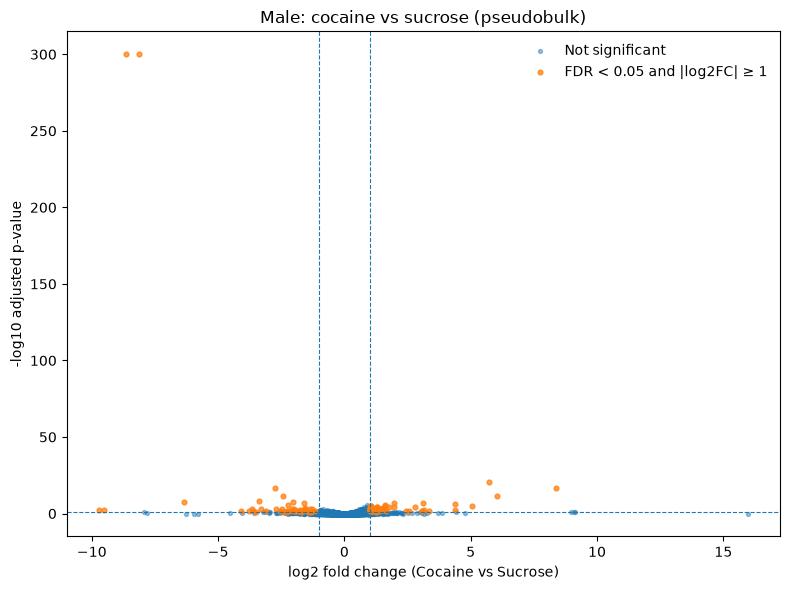

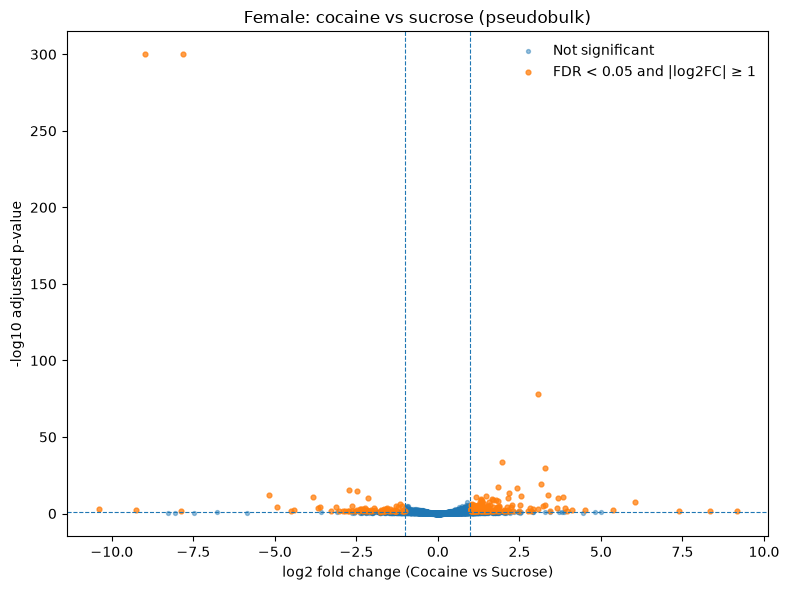

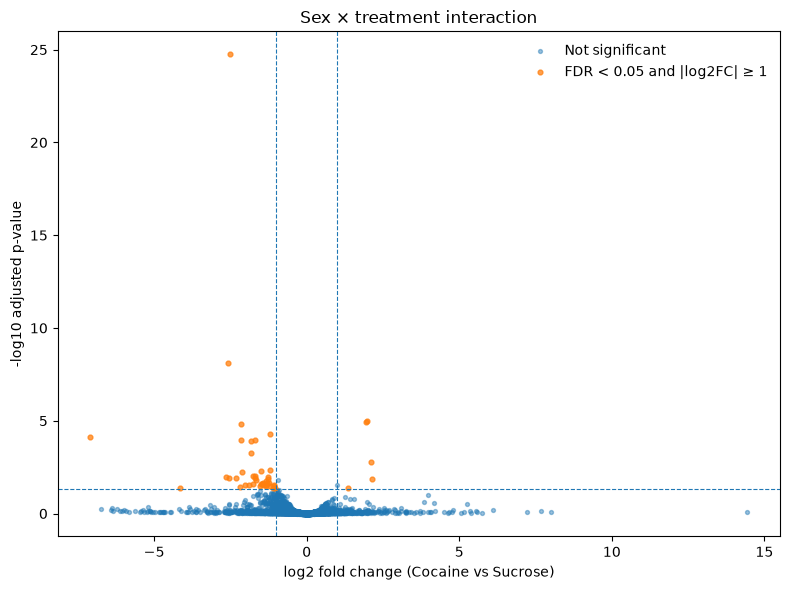

In [7]:
def volcano(df, title, filename, labels=("Ddc", "para")):
    x = df["log2FC"].to_numpy()
    y = -np.log10(df["padj"].clip(lower=1e-300).to_numpy())
    sig = df["significant"].to_numpy()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(x[~sig], y[~sig], s=8, alpha=0.45, label="Not significant")
    ax.scatter(x[sig], y[sig], s=12, alpha=0.75, label="FDR < 0.05 and |log2FC| ≥ 1")
    ax.axvline(1, linestyle="--", linewidth=0.8)
    ax.axvline(-1, linestyle="--", linewidth=0.8)
    ax.axhline(-np.log10(0.05), linestyle="--", linewidth=0.8)

    for gene in labels:
        hit = df[df["gene"].astype(str) == gene]
        if not hit.empty and np.isfinite(hit["log2FC"].iloc[0]) and np.isfinite(hit["padj"].iloc[0]):
            row = hit.iloc[0]
            ax.annotate(gene, (row["log2FC"], -np.log10(max(row["padj"], 1e-300))),
                        xytext=(5, 5), textcoords="offset points", fontsize=9)

    ax.set_xlabel("log2 fold change (Cocaine vs Sucrose)")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(title)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

volcano(male_treatment, "Male: cocaine vs sucrose (pseudobulk)", "fig4_volcano_male.png")
volcano(female_treatment, "Female: cocaine vs sucrose (pseudobulk)", "fig4_volcano_female.png")
volcano(sex_interaction, "Sex × treatment interaction", "fig4_volcano_interaction.png")

## 7. Descriptive male/female comparison

The number of significant genes is reported only as a **descriptive summary**. A sex-specific response is assessed statistically by the interaction contrast above.

In [8]:
summary = pd.DataFrame({
    "analysis": [
        "Female cocaine vs sucrose",
        "Male cocaine vs sucrose",
        "Sex × treatment interaction"
    ],
    "significant_genes_FDR_lt_0.05_abs_log2FC_ge_1": [
        int(female_treatment["significant"].sum()),
        int(male_treatment["significant"].sum()),
        int(sex_interaction["significant"].sum())
    ]
})
summary.to_csv(TABLE_DIR / "revised_DE_summary.csv", index=False)
print(summary.to_string(index=False))

                   analysis  significant_genes_FDR_lt_0.05_abs_log2FC_ge_1
  Female cocaine vs sucrose                                            246
    Male cocaine vs sucrose                                            109
Sex × treatment interaction                                             46


## 8. Pathway enrichment using only significant genes

The enrichment analysis is deliberately separated into significant and non-significant terms. The figure uses **only significant terms** at adjusted p < 0.05; the complete enrichment table is retained for transparency.

In [9]:
import gseapy as gp

ENRICH_LIBRARY = "Allele_LoF_Phenotypes_from_FlyBase_2017"

def enrich_de(df, label):
    genes = df.loc[df["significant"] & df["log2FC"].notna(), "gene"].astype(str).tolist()
    if len(genes) < 3:
        print(f"{label}: fewer than 3 significant genes; enrichment skipped.")
        return pd.DataFrame(), pd.DataFrame()

    enr = gp.enrichr(
        gene_list=genes,
        gene_sets=[ENRICH_LIBRARY],
        organism="fly",
        outdir=None,
    )
    res = enr.results.copy()
    res["significant"] = res["Adjusted P-value"] < 0.05
    sig = res[res["significant"]].copy()
    nonsig = res[~res["significant"]].copy()
    res.to_csv(TABLE_DIR / f"{label}_pathway_enrichment_all.csv", index=False)
    sig.to_csv(TABLE_DIR / f"{label}_pathway_enrichment_significant.csv", index=False)
    nonsig.to_csv(TABLE_DIR / f"{label}_pathway_enrichment_nonsignificant.csv", index=False)
    return sig, nonsig

male_enrich_sig, male_enrich_nonsig = enrich_de(male_treatment, "male")
female_enrich_sig, female_enrich_nonsig = enrich_de(female_treatment, "female")

print("Male significant enrichment terms:", len(male_enrich_sig))
print("Female significant enrichment terms:", len(female_enrich_sig))

Male significant enrichment terms: 0
Female significant enrichment terms: 0


## 9. Regenerate Figure 5 from the final enrichment tables

This replaces the previous manually/independently generated Figure 5. The figure is constructed directly from the same tables saved above.

In [10]:
def plot_enrichment(df, title, filename, top_n=10):
    if df.empty:
        print(f"No significant terms for {title}")
        return

    d = df.sort_values("Adjusted P-value").head(top_n).copy()
    d = d.iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(d["Term"], -np.log10(d["Adjusted P-value"].clip(lower=1e-300)))
    ax.set_xlabel("-log10 adjusted p-value")
    ax.set_ylabel("Enrichment term")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

plot_enrichment(
    male_enrich_sig,
    "Male cocaine-responsive genes: significant enrichment",
    "fig5_enrichment_male.png",
)
plot_enrichment(
    female_enrich_sig,
    "Female cocaine-responsive genes: significant enrichment",
    "fig5_enrichment_female.png",
)

No significant terms for Male cocaine-responsive genes: significant enrichment
No significant terms for Female cocaine-responsive genes: significant enrichment


## 10. Final consistency check

The following table is the single source of truth for the revised DE counts and interaction result. Use these values—not the old 50/46 values—in the report and rebuttal.

In [11]:
final_consistency = {
    "cells_final": int(adata.n_obs),
    "genes_in_normalized_object": int(adata.n_vars),
    "genes_tested_pseudobulk": int(pb_filtered.shape[1]),
    "female_sig": int(female_treatment["significant"].sum()),
    "male_sig": int(male_treatment["significant"].sum()),
    "interaction_sig": int(sex_interaction["significant"].sum()),
    "female_enrichment_sig_terms": int(len(female_enrich_sig)),
    "male_enrichment_sig_terms": int(len(male_enrich_sig)),
}
consistency_df = pd.DataFrame([final_consistency])
consistency_df.to_csv(TABLE_DIR / "FINAL_REVISED_ANALYSIS_SUMMARY.csv", index=False)
print(consistency_df.T)
print("\nFinal output files are in:", TABLE_DIR.resolve())

                                 0
cells_final                  88922
genes_in_normalized_object   11946
genes_tested_pseudobulk       9557
female_sig                     246
male_sig                       109
interaction_sig                 46
female_enrichment_sig_terms      0
male_enrichment_sig_terms        0

Final output files are in: /home/tanvir-ahmed/scproject2-drosophila-brain/results/tables


### Important interpretation for the final report

Do **not** retain the old statement that “50 vs 46 proves a milder sex-biased response.” Those numbers came from the previous cell-level workflow. The revised manuscript should report the new pseudobulk counts and, most importantly, the sex × treatment interaction result.

If the interaction is not significant, say so explicitly. That is a valid scientific result.

### Reviewer coverage

This notebook directly addresses major comments 2–7 and minor comments 1–2:
- no DE on scaled data;
- no 2,000-HVG restriction for DE;
- biological replicates are used as the inferential units;
- direct sex × treatment interaction test;
- low-count/undefined-fold-change handling is documented;
- Figure 5 is regenerated from final tables;
- significant and non-significant enrichment terms are separated;
- volcano plots label `Ddc` and `para` when present.